# CPI / PMI 原始数据 Bry-Boschan 四象限识别

使用 `M0000612.pkl` 作为通胀，`M0017126.pkl` 作为经济增长。对两条原始月度序列直接运行 Bry-Boschan-like 拐点识别，并把识别结果与给定参考四象限走势进行逐月对比。

特别限制：PMI 作为经济增长变量时，BB 高点必须大于 50，低点必须小于 50。

In [14]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
PKL_DIR = ROOT / "output_宏观_pkl"
OUT = ROOT / "cpi_pmi_bb_reference_comparison_output"
OUT.mkdir(exist_ok=True)

START_DATE = pd.Timestamp("2026-05-31")

# 只使用参考资料覆盖的样本期。
ANALYSIS_START = pd.Timestamp("2002-01-31")
ANALYSIS_END = pd.Timestamp("2020-11-30")

SERIES = {
    "growth": {"code": "M0017126", "name": "中国:制造业PMI", "threshold": 50.0},
    "inflation": {"code": "M0000612", "name": "中国:CPI:当月同比", "threshold": None},
}

# BB 参数。PMI 的高低点还会额外经过 50 阈值过滤。
BB_WINDOW = 5
MIN_PHASE = 5
MIN_CYCLE = 15

## 1. 读取 CPI / PMI 原始月度数据

In [15]:
def _first_numeric_series(obj) -> pd.Series:
    if isinstance(obj, pd.Series):
        return pd.to_numeric(obj, errors="coerce")
    if isinstance(obj, pd.DataFrame):
        numeric = obj.apply(pd.to_numeric, errors="coerce")
        cols = [col for col in numeric.columns if numeric[col].notna().any()]
        if not cols:
            raise ValueError("DataFrame 中没有可转成数值的列")
        return numeric[cols[0]]
    return pd.to_numeric(pd.Series(obj), errors="coerce")


def read_monthly_pkl(code: str, start_date: pd.Timestamp = START_DATE) -> pd.Series:
    path = PKL_DIR / f"{code}.pkl"
    if not path.exists():
        raise FileNotFoundError(path)

    raw = _first_numeric_series(pd.read_pickle(path)).dropna()
    idx_text = pd.Series(raw.index.astype(str)).str.strip()
    parsed_idx = pd.to_datetime(idx_text, errors="coerce")

    if parsed_idx.notna().any():
        s = pd.Series(raw.to_numpy(), index=parsed_idx)
        s = s[s.index.notna()]
    else:
        dates = [start_date - pd.offsets.MonthEnd(i) for i in range(len(raw))]
        s = pd.Series(raw.to_numpy(), index=pd.DatetimeIndex(dates))

    month_end = pd.DatetimeIndex(s.index).to_period("M").to_timestamp("M")
    monthly = pd.Series(s.to_numpy(), index=month_end).sort_index().groupby(level=0).last()
    regular = monthly.reindex(pd.date_range(monthly.index.min(), monthly.index.max(), freq="ME"))
    return regular.interpolate(limit=2).dropna().rename(code)


raw_series_full = {factor: read_monthly_pkl(info["code"]) for factor, info in SERIES.items()}
raw_series = {
    factor: series.loc[(series.index >= ANALYSIS_START) & (series.index <= ANALYSIS_END)]
    for factor, series in raw_series_full.items()
}
raw_data = pd.concat(
    {
        "growth_raw": raw_series["growth"],
        "inflation_raw": raw_series["inflation"],
    },
    axis=1,
).rename_axis("date")

data_overview = pd.DataFrame([
    {
        "factor": factor,
        "code": info["code"],
        "name": info["name"],
        "full_start": raw_series_full[factor].index.min(),
        "full_end": raw_series_full[factor].index.max(),
        "analysis_start": raw_series[factor].index.min(),
        "analysis_end": raw_series[factor].index.max(),
        "analysis_nobs": len(raw_series[factor]),
        "last_value": raw_series[factor].iloc[-1],
    }
    for factor, info in SERIES.items()
])

display(data_overview)
display(raw_data.tail(12))

C:\Users\16492\AppData\Local\Temp\ipykernel_14188\1100673024.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed_idx = pd.to_datetime(idx_text, errors="coerce")
C:\Users\16492\AppData\Local\Temp\ipykernel_14188\1100673024.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed_idx = pd.to_datetime(idx_text, errors="coerce")


,factor,code,name,full_start,full_end,analysis_start,analysis_end,analysis_nobs,last_value
0,growth,M0017126,中国:制造业PMI,2005-01-31,2026-05-31,2005-01-31,2020-11-30,191,52.1
1,inflation,M0000612,中国:CPI:当月同比,1987-01-31,2026-05-31,2002-01-31,2020-11-30,227,-0.5


,growth_raw,inflation_raw
date,,
2019-12-31,50.2,4.5
2020-01-31,50.0,5.4
2020-02-29,35.7,5.2
2020-03-31,52.0,4.3
2020-04-30,50.8,3.3
2020-05-31,50.6,2.4
2020-06-30,50.9,2.5
2020-07-31,51.1,2.7
2020-08-31,51.0,2.4


## 2. Bry-Boschan-like 拐点函数

In [16]:
def local_turns(y: pd.Series, window: int = 5, threshold: float | None = None) -> pd.DataFrame:
    y = y.dropna()
    rows = []
    for i in range(window, len(y) - window):
        block = y.iloc[i - window : i + window + 1]
        value = y.iloc[i]

        is_peak = value == block.max() and value > y.iloc[i - 1] and value > y.iloc[i + 1]
        is_trough = value == block.min() and value < y.iloc[i - 1] and value < y.iloc[i + 1]

        if threshold is not None:
            is_peak = is_peak and value > threshold
            is_trough = is_trough and value < threshold

        if is_peak:
            rows.append({"date": y.index[i], "type": "peak", "value": value})
        if is_trough:
            rows.append({"date": y.index[i], "type": "trough", "value": value})

    return pd.DataFrame(rows, columns=["date", "type", "value"]).sort_values("date").reset_index(drop=True)


def alternate(turns: pd.DataFrame) -> pd.DataFrame:
    if turns.empty:
        return turns.copy()
    kept = []
    for row in turns.to_dict("records"):
        if not kept or row["type"] != kept[-1]["type"]:
            kept.append(row)
            continue
        better_peak = row["type"] == "peak" and row["value"] > kept[-1]["value"]
        better_trough = row["type"] == "trough" and row["value"] < kept[-1]["value"]
        if better_peak or better_trough:
            kept[-1] = row
    return pd.DataFrame(kept, columns=turns.columns)


def enforce_lengths(turns: pd.DataFrame, min_phase: int = 5, min_cycle: int = 15) -> pd.DataFrame:
    turns = alternate(turns)
    changed = True
    while changed and len(turns) > 2:
        changed = False
        turns = turns.reset_index(drop=True)

        for i in range(len(turns) - 1):
            months = (turns.loc[i + 1, "date"].to_period("M") - turns.loc[i, "date"].to_period("M")).n
            if months < min_phase:
                amp_left = abs(turns.loc[i, "value"] - turns["value"].median())
                amp_right = abs(turns.loc[i + 1, "value"] - turns["value"].median())
                turns = turns.drop(i if amp_left < amp_right else i + 1)
                changed = True
                break
        if changed:
            turns = alternate(turns)
            continue

        for i in range(len(turns) - 2):
            months = (turns.loc[i + 2, "date"].to_period("M") - turns.loc[i, "date"].to_period("M")).n
            if turns.loc[i, "type"] == turns.loc[i + 2, "type"] and months < min_cycle:
                if turns.loc[i, "type"] == "peak":
                    drop_i = i if turns.loc[i, "value"] < turns.loc[i + 2, "value"] else i + 2
                else:
                    drop_i = i if turns.loc[i, "value"] > turns.loc[i + 2, "value"] else i + 2
                turns = turns.drop(drop_i)
                changed = True
                break
        turns = alternate(turns)
    return turns.reset_index(drop=True)


def bry_boschan_like(
    y: pd.Series,
    window: int = BB_WINDOW,
    min_phase: int = MIN_PHASE,
    min_cycle: int = MIN_CYCLE,
    threshold: float | None = None,
) -> pd.DataFrame:
    turns = enforce_lengths(local_turns(y, window=window, threshold=threshold), min_phase=min_phase, min_cycle=min_cycle)
    if turns.empty:
        turns["turn"] = []
        return turns
    turns["turn"] = turns["type"].map({"peak": "高点", "trough": "低点"})
    return turns


def phase_by_turns(index: pd.DatetimeIndex, turns: pd.DataFrame) -> pd.Series:
    phase = pd.Series(index=index, dtype="object")
    if turns.empty or len(index) == 0:
        return phase
    turns = turns.sort_values("date").reset_index(drop=True)

    first = turns.loc[0]
    before_first = "上行" if first["type"] == "peak" else "下行"
    phase.loc[index < first["date"]] = before_first

    for i, row in turns.iterrows():
        start = row["date"]
        end = turns.loc[i + 1, "date"] if i < len(turns) - 1 else index[-1] + pd.offsets.MonthEnd(1)
        after_turn = "下行" if row["type"] == "peak" else "上行"
        phase.loc[(index >= start) & (index < end)] = after_turn
    return phase

## 3. 对 CPI / PMI 原始数据跑 BB

In [17]:
turn_rows = []
for factor, series in raw_series.items():
    threshold = SERIES[factor]["threshold"]
    turns = bry_boschan_like(series, threshold=threshold)
    turns.insert(0, "factor", factor)
    turns.insert(1, "code", SERIES[factor]["code"])
    turns.insert(2, "name", SERIES[factor]["name"])
    turns.insert(3, "threshold", threshold)
    turn_rows.append(turns)

turning_points = pd.concat(turn_rows, ignore_index=True)

common_index = raw_series["growth"].index.intersection(raw_series["inflation"].index)
states = pd.DataFrame(index=common_index)
states["growth_value"] = raw_series["growth"].reindex(common_index)
states["inflation_value"] = raw_series["inflation"].reindex(common_index)
states["growth_phase"] = phase_by_turns(common_index, turning_points[turning_points["factor"].eq("growth")])
states["inflation_phase"] = phase_by_turns(common_index, turning_points[turning_points["factor"].eq("inflation")])
states["macro_state"] = "经济" + states["growth_phase"] + " + 通胀" + states["inflation_phase"]

latest = states.dropna(subset=["macro_state"]).iloc[-1]
latest_summary = pd.DataFrame([{
    "latest_state_date": latest.name,
    "growth_phase": latest["growth_phase"],
    "inflation_phase": latest["inflation_phase"],
    "macro_state": latest["macro_state"],
    "growth_value": latest["growth_value"],
    "inflation_value": latest["inflation_value"],
    "growth_turns": len(turning_points[turning_points["factor"].eq("growth")]),
    "inflation_turns": len(turning_points[turning_points["factor"].eq("inflation")]),
    "pmi_peak_must_gt": SERIES["growth"]["threshold"],
    "pmi_trough_must_lt": SERIES["growth"]["threshold"],
}])

display(latest_summary)
display(turning_points)
display(states.tail(24))

C:\Users\16492\AppData\Local\Temp\ipykernel_14188\2408767073.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  turning_points = pd.concat(turn_rows, ignore_index=True)


,latest_state_date,growth_phase,inflation_phase,macro_state,growth_value,inflation_value,growth_turns,inflation_turns,pmi_peak_must_gt,pmi_trough_must_lt
0,2020-11-30,上行,下行,经济上行 + 通胀下行,52.1,-0.5,8,8,50.0,50.0


,factor,code,name,threshold,date,type,value,turn
0,growth,M0017126,中国:制造业PMI,50.0,2008-04-30,peak,59.2000,高点
1,growth,M0017126,中国:制造业PMI,50.0,2008-11-30,trough,38.8000,低点
2,growth,M0017126,中国:制造业PMI,50.0,2009-12-31,peak,56.6000,高点
3,growth,M0017126,中国:制造业PMI,50.0,2011-11-30,trough,49.0000,低点
4,growth,M0017126,中国:制造业PMI,50.0,2012-04-30,peak,53.3000,高点
5,growth,M0017126,中国:制造业PMI,50.0,2016-02-29,trough,49.0000,低点
6,growth,M0017126,中国:制造业PMI,50.0,2017-09-30,peak,52.4000,高点
7,growth,M0017126,中国:制造业PMI,50.0,2020-02-29,trough,35.7000,低点
8,inflation,M0000612,中国:CPI:当月同比,NaN,2006-03-31,trough,0.8000,低点
9,inflation,M0000612,中国:CPI:当月同比,NaN,2008-02-29,peak,8.7000,高点


,growth_value,inflation_value,growth_phase,inflation_phase,macro_state
2018-12-31,49.4,1.9,下行,下行,经济下行 + 通胀下行
2019-01-31,49.5,1.7,下行,下行,经济下行 + 通胀下行
2019-02-28,49.2,1.5,下行,上行,经济下行 + 通胀上行
2019-03-31,50.5,2.3,下行,上行,经济下行 + 通胀上行
2019-04-30,50.1,2.5,下行,上行,经济下行 + 通胀上行
2019-05-31,49.4,2.7,下行,上行,经济下行 + 通胀上行
2019-06-30,49.4,2.7,下行,上行,经济下行 + 通胀上行
2019-07-31,49.7,2.8,下行,上行,经济下行 + 通胀上行
2019-08-31,49.5,2.8,下行,上行,经济下行 + 通胀上行
2019-09-30,49.8,3.0,下行,上行,经济下行 + 通胀上行


## 4. 参考四象限走势

In [18]:
# 区间按“起点包含、终点不包含”处理，避免边界月重复归属。
REFERENCE_REGIMES = [
    # 经济上行 + 通胀下行（复苏）
    ("2003-05", "2003-06", "复苏", 1, -1),
    ("2004-12", "2006-03", "复苏", 1, -1),
    ("2008-04", "2008-05", "复苏", 1, -1),
    ("2009-02", "2009-07", "复苏", 1, -1),
    ("2012-08", "2012-09", "复苏", 1, -1),
    ("2013-02", "2013-05", "复苏", 1, -1),
    ("2015-03", "2015-06", "复苏", 1, -1),
    ("2017-02", "2017-06", "复苏", 1, -1),
    ("2020-03", "2020-11", "复苏", 1, -1),
    # 经济上行 + 通胀上行（过热）
    ("2002-01", "2003-02", "过热", 1, 1),
    ("2003-06", "2004-03", "过热", 1, 1),
    ("2006-03", "2008-04", "过热", 1, 1),
    ("2009-07", "2010-02", "过热", 1, 1),
    ("2010-10", "2011-06", "过热", 1, 1),
    ("2012-09", "2013-02", "过热", 1, 1),
    ("2013-05", "2013-08", "过热", 1, 1),
    ("2016-02", "2017-02", "过热", 1, 1),
    ("2019-08", "2019-12", "过热", 1, 1),
    # 经济下行 + 通胀上行（滞涨）
    ("2003-03", "2003-05", "滞涨", -1, 1),
    ("2004-09", "2004-12", "滞涨", -1, 1),
    ("2008-05", "2009-02", "滞涨", -1, 1),
    ("2011-07", "2012-08", "滞涨", -1, 1),
    ("2014-08", "2015-03", "滞涨", -1, 1),
    ("2015-06", "2015-10", "滞涨", -1, 1),
    ("2017-06", "2017-07", "滞涨", -1, 1),
    ("2017-10", "2018-04", "滞涨", -1, 1),
    ("2018-07", "2019-02", "滞涨", -1, 1),
    ("2019-05", "2019-08", "滞涨", -1, 1),
    ("2020-02", "2020-03", "滞涨", -1, 1),
    # 经济下行 + 通胀下行（衰退）
    ("2003-02", "2003-03", "衰退", -1, -1),
    ("2004-03", "2004-09", "衰退", -1, -1),
    ("2009-02", "2010-10", "衰退", -1, -1),
    ("2011-06", "2011-07", "衰退", -1, -1),
    ("2013-08", "2013-10", "衰退", -1, -1),
    ("2015-10", "2016-02", "衰退", -1, -1),
    ("2017-07", "2017-10", "衰退", -1, -1),
    ("2018-04", "2018-07", "衰退", -1, -1),
    ("2019-02", "2019-05", "衰退", -1, -1),
    ("2019-12", "2020-02", "衰退", -1, -1),
]

STATE_TO_CODE = {"复苏": 0, "过热": 1, "滞涨": 2, "衰退": 3}
CODE_TO_STATE = {v: k for k, v in STATE_TO_CODE.items()}


def month_start(text: str) -> pd.Timestamp:
    return pd.Period(text, freq="M").to_timestamp("M")


def build_reference(index: pd.DatetimeIndex) -> pd.DataFrame:
    ref = pd.DataFrame(index=index)
    ref["reference_state"] = pd.NA
    ref["reference_growth_direction"] = np.nan
    ref["reference_inflation_direction"] = np.nan

    for start_text, end_text, state_name, growth_dir, inflation_dir in REFERENCE_REGIMES:
        start = month_start(start_text)
        end = month_start(end_text)
        mask = (ref.index >= start) & (ref.index < end)
        ref.loc[mask, "reference_state"] = state_name
        ref.loc[mask, "reference_growth_direction"] = growth_dir
        ref.loc[mask, "reference_inflation_direction"] = inflation_dir

    ref = ref.dropna(subset=["reference_state"])
    ref["reference_growth_direction"] = ref["reference_growth_direction"].astype(int)
    ref["reference_inflation_direction"] = ref["reference_inflation_direction"].astype(int)
    ref["reference_state_code"] = ref["reference_state"].map(STATE_TO_CODE).astype(int)
    return ref


reference = build_reference(states.index)
display(reference.head())
display(reference.tail())
display(reference["reference_state"].value_counts().to_frame("months"))

,reference_state,reference_growth_direction,reference_inflation_direction,reference_state_code
2005-01-31,复苏,1,-1,0
2005-02-28,复苏,1,-1,0
2005-03-31,复苏,1,-1,0
2005-04-30,复苏,1,-1,0
2005-05-31,复苏,1,-1,0


,reference_state,reference_growth_direction,reference_inflation_direction,reference_state_code
2020-06-30,复苏,1,-1,0
2020-07-31,复苏,1,-1,0
2020-08-31,复苏,1,-1,0
2020-09-30,复苏,1,-1,0
2020-10-31,复苏,1,-1,0


,months
reference_state,
过热,57
滞涨,51
衰退,38
复苏,34


## 5. 与参考走势逐月对比

In [19]:
comparison = pd.concat([states, reference], axis=1, join="inner").dropna(subset=["macro_state", "reference_state"])
comparison["bb_growth_direction"] = comparison["growth_phase"].map({"上行": 1, "下行": -1}).astype(int)
comparison["bb_inflation_direction"] = comparison["inflation_phase"].map({"上行": 1, "下行": -1}).astype(int)

def macro_state_from_dirs(growth_dir: int, inflation_dir: int) -> str:
    if growth_dir == 1 and inflation_dir == -1:
        return "复苏"
    if growth_dir == 1 and inflation_dir == 1:
        return "过热"
    if growth_dir == -1 and inflation_dir == 1:
        return "滞涨"
    return "衰退"

comparison["bb_state"] = [
    macro_state_from_dirs(g, i)
    for g, i in zip(comparison["bb_growth_direction"], comparison["bb_inflation_direction"])
]
comparison["bb_state_code"] = comparison["bb_state"].map(STATE_TO_CODE).astype(int)
comparison["growth_match"] = comparison["bb_growth_direction"].eq(comparison["reference_growth_direction"])
comparison["inflation_match"] = comparison["bb_inflation_direction"].eq(comparison["reference_inflation_direction"])
comparison["state_match"] = comparison["bb_state"].eq(comparison["reference_state"])

state_accuracy_by_ref = (
    comparison.groupby("reference_state")["state_match"]
    .agg(months="size", accuracy="mean")
    .reindex(["复苏", "过热", "滞涨", "衰退"])
)

accuracy_summary = pd.DataFrame([{
    "start": comparison.index.min(),
    "end": comparison.index.max(),
    "months": len(comparison),
    "state_accuracy": comparison["state_match"].mean(),
    "growth_direction_accuracy": comparison["growth_match"].mean(),
    "inflation_direction_accuracy": comparison["inflation_match"].mean(),
    "balanced_state_accuracy": state_accuracy_by_ref["accuracy"].mean(),
}])

confusion = pd.crosstab(
    comparison["reference_state"],
    comparison["bb_state"],
    rownames=["reference"],
    colnames=["bb"],
).reindex(index=["复苏", "过热", "滞涨", "衰退"], columns=["复苏", "过热", "滞涨", "衰退"], fill_value=0)

display(accuracy_summary)
display(state_accuracy_by_ref)
display(confusion)
display(comparison[~comparison["state_match"]].head(30))

raw_data.to_csv(OUT / "cpi_pmi_raw_series.csv", encoding="utf-8-sig")
turning_points.to_csv(OUT / "cpi_pmi_bb_turning_points.csv", index=False, encoding="utf-8-sig")
states.rename_axis("date").reset_index().to_csv(OUT / "cpi_pmi_bb_states_by_month.csv", index=False, encoding="utf-8-sig")
reference.rename_axis("date").reset_index().to_csv(OUT / "reference_macro_states.csv", index=False, encoding="utf-8-sig")
comparison.rename_axis("date").reset_index().to_csv(OUT / "cpi_pmi_bb_vs_reference_comparison.csv", index=False, encoding="utf-8-sig")
accuracy_summary.to_csv(OUT / "cpi_pmi_bb_vs_reference_accuracy_summary.csv", index=False, encoding="utf-8-sig")
confusion.to_csv(OUT / "cpi_pmi_bb_vs_reference_confusion.csv", encoding="utf-8-sig")

,start,end,months,state_accuracy,growth_direction_accuracy,inflation_direction_accuracy,balanced_state_accuracy
0,2005-01-31,2020-10-31,180,0.422222,0.722222,0.55,0.418473


,months,accuracy
reference_state,,
复苏,34,0.647059
过热,57,0.614035
滞涨,51,0.254902
衰退,38,0.157895


bb,复苏,过热,滞涨,衰退
reference,,,,
复苏,22,4,3,5
过热,2,35,12,8
滞涨,9,1,13,28
衰退,5,7,20,6


,growth_value,inflation_value,growth_phase,inflation_phase,macro_state,reference_state,reference_growth_direction,reference_inflation_direction,reference_state_code,bb_growth_direction,bb_inflation_direction,bb_state,bb_state_code,growth_match,inflation_match,state_match
2008-02-29,53.4,8.7,上行,下行,经济上行 + 通胀下行,过热,1,1,1,1,-1,复苏,0,True,False,False
2008-03-31,58.4,8.3,上行,下行,经济上行 + 通胀下行,过热,1,1,1,1,-1,复苏,0,True,False,False
2008-04-30,59.2,8.5,下行,下行,经济下行 + 通胀下行,复苏,1,-1,0,-1,-1,衰退,3,False,True,False
2008-05-31,53.3,7.7,下行,下行,经济下行 + 通胀下行,滞涨,-1,1,2,-1,-1,衰退,3,True,False,False
2008-06-30,52.0,7.1,下行,下行,经济下行 + 通胀下行,滞涨,-1,1,2,-1,-1,衰退,3,True,False,False
2008-07-31,48.4,6.3,下行,下行,经济下行 + 通胀下行,滞涨,-1,1,2,-1,-1,衰退,3,True,False,False
2008-08-31,48.4,4.9,下行,下行,经济下行 + 通胀下行,滞涨,-1,1,2,-1,-1,衰退,3,True,False,False
2008-09-30,51.2,4.6,下行,下行,经济下行 + 通胀下行,滞涨,-1,1,2,-1,-1,衰退,3,True,False,False
2008-10-31,44.6,4.0,下行,下行,经济下行 + 通胀下行,滞涨,-1,1,2,-1,-1,衰退,3,True,False,False
2008-11-30,38.8,2.4,上行,下行,经济上行 + 通胀下行,滞涨,-1,1,2,1,-1,复苏,0,False,False,False


## 6. 对比图

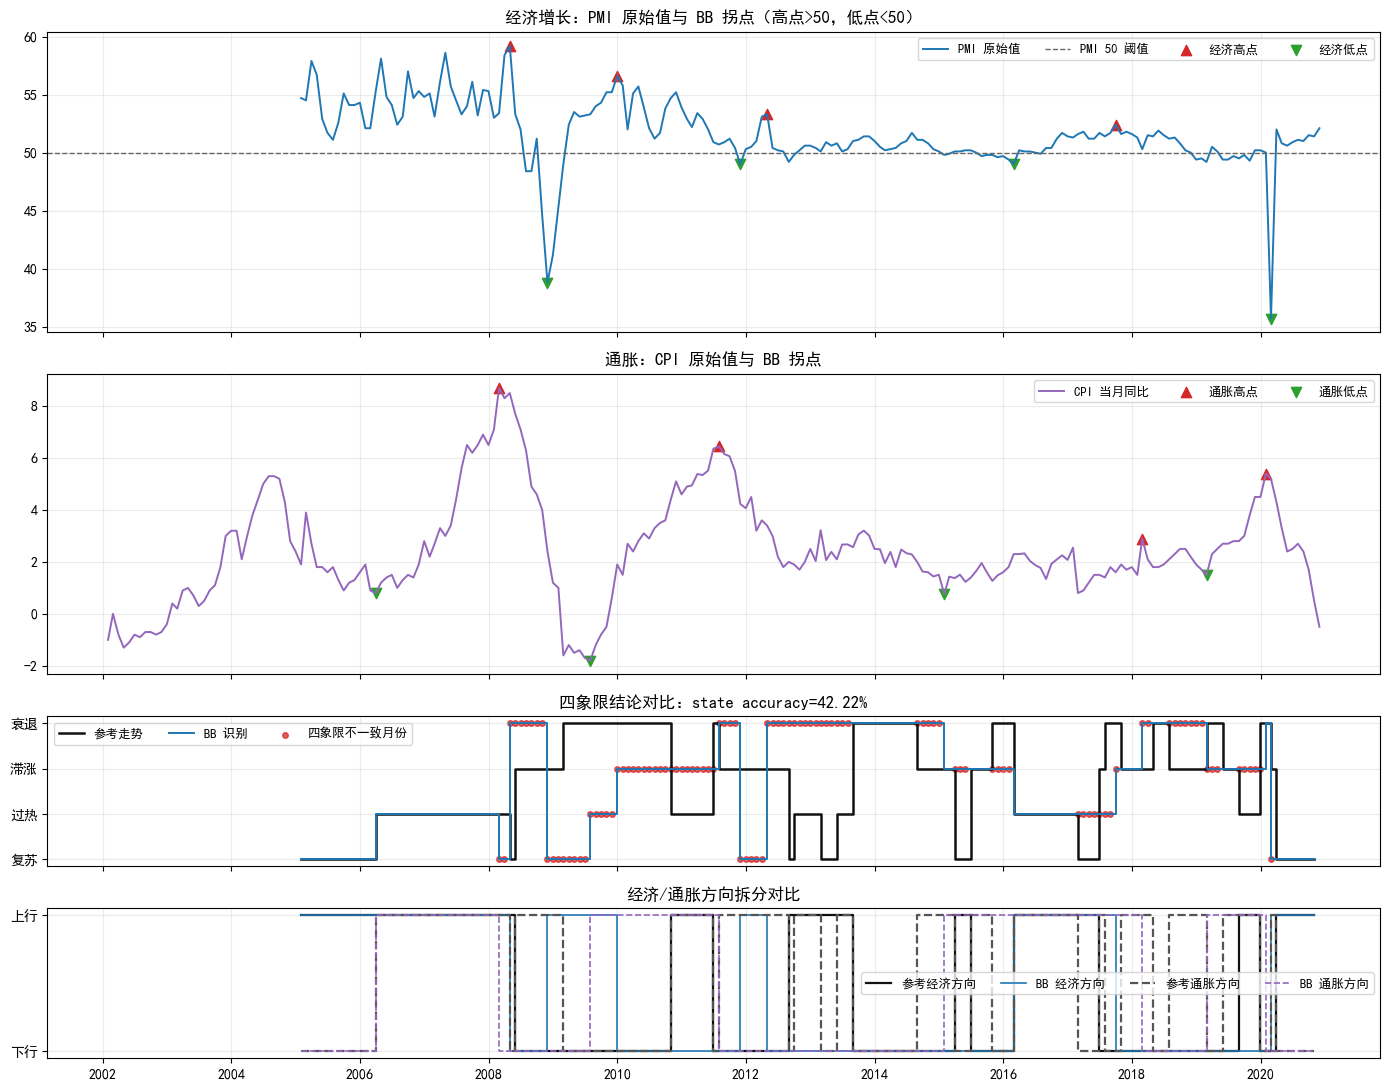

图已导出：c:\Users\16492\Desktop\实习内容\数据处理\data\cpi_pmi_bb_reference_comparison_output\cpi_pmi_bb_vs_reference_comparison.png
表格已导出到：c:\Users\16492\Desktop\实习内容\数据处理\data\cpi_pmi_bb_reference_comparison_output


In [20]:
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True, gridspec_kw={"height_ratios": [2, 2, 1, 1]})

growth_turns = turning_points[turning_points["factor"].eq("growth")]
inflation_turns = turning_points[turning_points["factor"].eq("inflation")]

ax = axes[0]
ax.plot(raw_series["growth"].index, raw_series["growth"].values, color="#1f77b4", linewidth=1.4, label="PMI 原始值")
ax.axhline(50, color="#666666", linestyle="--", linewidth=1.0, label="PMI 50 阈值")
ax.scatter(growth_turns[growth_turns["type"].eq("peak")]["date"], growth_turns[growth_turns["type"].eq("peak")]["value"], color="#d62728", marker="^", s=55, label="经济高点")
ax.scatter(growth_turns[growth_turns["type"].eq("trough")]["date"], growth_turns[growth_turns["type"].eq("trough")]["value"], color="#2ca02c", marker="v", s=55, label="经济低点")
ax.set_title("经济增长：PMI 原始值与 BB 拐点（高点>50，低点<50）")
ax.grid(alpha=0.25)
ax.legend(ncol=4, fontsize=9)

ax = axes[1]
ax.plot(raw_series["inflation"].index, raw_series["inflation"].values, color="#9467bd", linewidth=1.4, label="CPI 当月同比")
ax.scatter(inflation_turns[inflation_turns["type"].eq("peak")]["date"], inflation_turns[inflation_turns["type"].eq("peak")]["value"], color="#d62728", marker="^", s=55, label="通胀高点")
ax.scatter(inflation_turns[inflation_turns["type"].eq("trough")]["date"], inflation_turns[inflation_turns["type"].eq("trough")]["value"], color="#2ca02c", marker="v", s=55, label="通胀低点")
ax.set_title("通胀：CPI 原始值与 BB 拐点")
ax.grid(alpha=0.25)
ax.legend(ncol=3, fontsize=9)

ax = axes[2]
ax.step(comparison.index, comparison["reference_state_code"], where="post", color="#111111", linewidth=1.8, label="参考走势")
ax.step(comparison.index, comparison["bb_state_code"], where="post", color="#1f77b4", linewidth=1.4, label="BB 识别")
wrong = comparison[~comparison["state_match"]]
if not wrong.empty:
    ax.scatter(wrong.index, wrong["bb_state_code"], color="#d62728", s=16, alpha=0.75, label="四象限不一致月份")
ax.set_yticks([0, 1, 2, 3])
ax.set_yticklabels([CODE_TO_STATE[i] for i in [0, 1, 2, 3]])
ax.set_title(f"四象限结论对比：state accuracy={accuracy_summary.loc[0, 'state_accuracy']:.2%}")
ax.grid(alpha=0.25)
ax.legend(ncol=3, fontsize=9)

ax = axes[3]
ax.step(comparison.index, comparison["reference_growth_direction"], where="post", color="#111111", linewidth=1.6, label="参考经济方向")
ax.step(comparison.index, comparison["bb_growth_direction"], where="post", color="#1f77b4", linewidth=1.2, label="BB 经济方向")
ax.step(comparison.index, comparison["reference_inflation_direction"], where="post", color="#555555", linewidth=1.6, linestyle="--", label="参考通胀方向")
ax.step(comparison.index, comparison["bb_inflation_direction"], where="post", color="#9467bd", linewidth=1.2, linestyle="--", label="BB 通胀方向")
ax.set_yticks([-1, 1])
ax.set_yticklabels(["下行", "上行"])
ax.set_title("经济/通胀方向拆分对比")
ax.grid(alpha=0.25)
ax.legend(ncol=4, fontsize=9)

fig.tight_layout()
fig.savefig(OUT / "cpi_pmi_bb_vs_reference_comparison.png", dpi=170)
plt.show()

print(f"图已导出：{OUT / 'cpi_pmi_bb_vs_reference_comparison.png'}")
print(f"表格已导出到：{OUT}")